--- RAW DATA PREVIEW ---
   OrderID   Product  Quantity  Price       Date
0        1  Keyboard       2.0    500 2026-01-01
1        2   Monitor       2.0   8000 2026-01-02
2        3    Laptop       4.0   1500 2026-01-03
3        4  Keyboard       2.0  45000 2026-01-04
4        5  Keyboard       2.0  45000 2026-01-05

Missing values checking:
 OrderID     0
Product     0
Quantity    6
Price       0
Date        0
dtype: int64

--- CLEANED DATA (No Missing Values) ---
OrderID        0
Product        0
Quantity       0
Price          0
Date           0
Total_Sales    0
dtype: int64

--- TOTAL SALES BY PRODUCT ---
    Product  Total_Sales
2   Monitor    1698500.0
3     Mouse    1532500.0
0  Keyboard    1514500.0
1    Laptop     645000.0


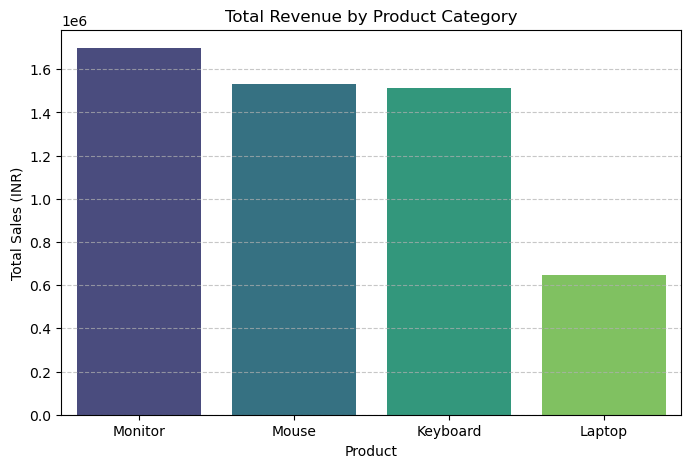

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)
data = {
    'OrderID': range(1, 101),
    'Product': np.random.choice(['Laptop', 'Mouse', 'Keyboard', 'Monitor'], 100),
    'Quantity': np.random.randint(1, 6, 100),
    'Price': np.random.choice([500, 1500, 8000, 45000], 100),
    'Date': pd.date_range(start='2026-01-01', periods=100, freq='D')
}
df = pd.DataFrame(data)


df.loc[10:15, 'Quantity'] = np.nan

print("--- RAW DATA PREVIEW ---")
print(df.head())
print("\nMissing values checking:\n", df.isnull().sum())

# 2. DATA CLEANING & PRE-PROCESSING

df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Naya logic lagana: Total Sales = Quantity * Price
df['Total_Sales'] = df['Quantity'] * df['Price']

print("\n--- CLEANED DATA (No Missing Values) ---")
print(df.isnull().sum())

# 3. EXPLORATORY DATA ANALYSIS (EDA)
#(Aggregation & Grouping)
product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()
product_sales = product_sales.sort_values(by='Total_Sales', ascending=False)

print("\n--- TOTAL SALES BY PRODUCT ---")
print(product_sales)

# 4. DATA VISUALIZATION

plt.figure(figsize=(8, 5))
sns.barplot(x='Product', y='Total_Sales', data=product_sales, hue='Product', palette='viridis', legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product')
plt.ylabel('Total Sales (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()